In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def f(t, nmax, T):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(2*T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+2*T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(3*T-t) )
    return res/(8.0*np.pi)

In [4]:
gsq=0.050000
beta=1.0/gsq

In [5]:
masses_=[]

In [6]:
beta

20.0

In [7]:
T=16
Nt=24 # 240

In [8]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

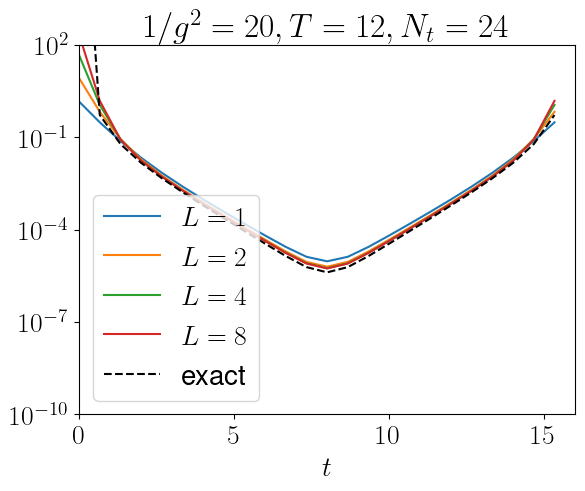

In [9]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, beta*l1_1, label="$L=1$" )
plt.plot( xx, beta*l2_1, label="$L=2$" )
plt.plot( xx, beta*l4_1, label="$L=4$" )
plt.plot( xx, beta*l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [10]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [11]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [12]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

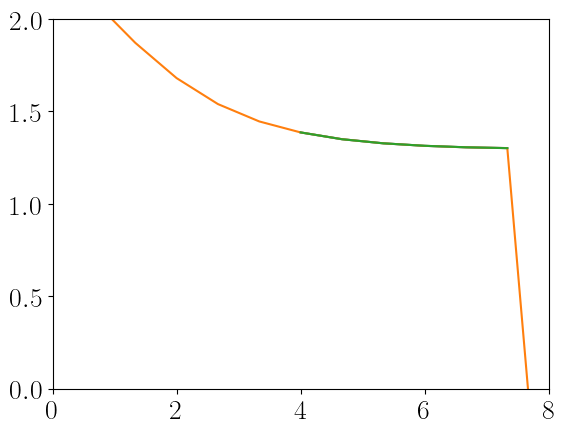

In [13]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [14]:
masses_.append([1, Nt, opt[0][0]])

In [15]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [16]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

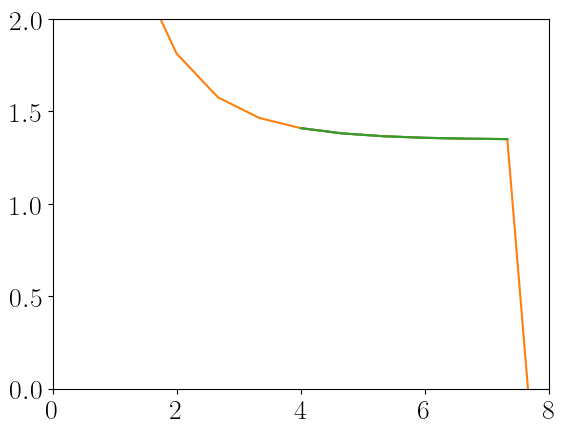

In [17]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [18]:
masses_.append([2, Nt, opt[0][0]])

In [19]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [20]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

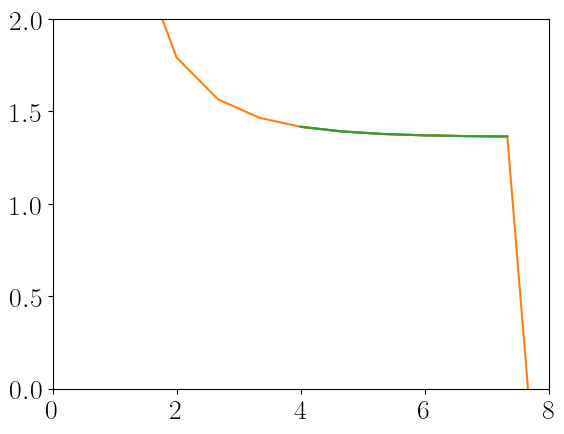

In [21]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [22]:
masses_.append([4, Nt, opt[0][0]])

In [23]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [24]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

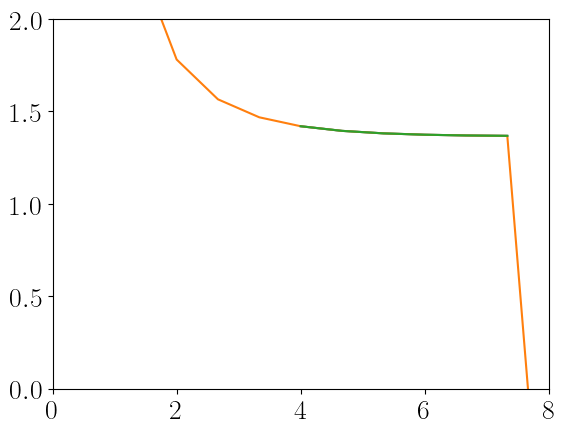

In [25]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [26]:
masses_.append([8, Nt, opt[0][0]])

In [27]:
T=16
Nt=48 # 240

In [28]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

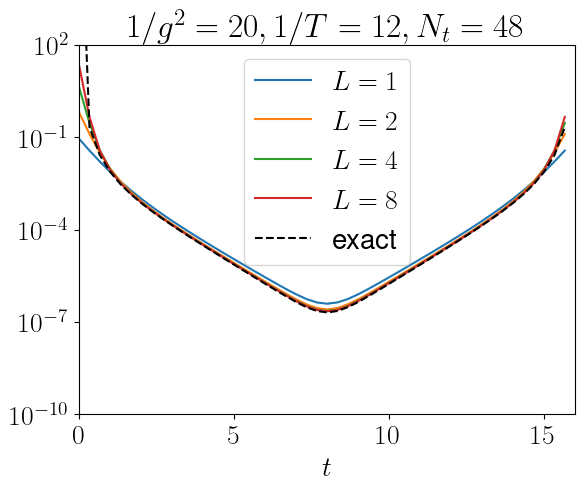

In [29]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [30]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [31]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [32]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

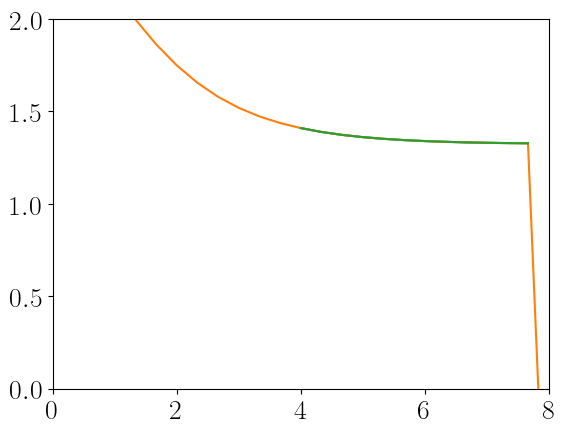

In [33]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [34]:
masses_.append([1, Nt, opt[0][0]])

In [35]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [36]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

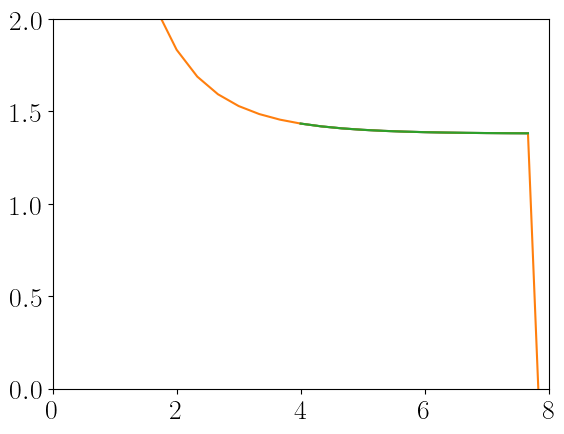

In [37]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [38]:
masses_.append([2, Nt, opt[0][0]])

In [39]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [40]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

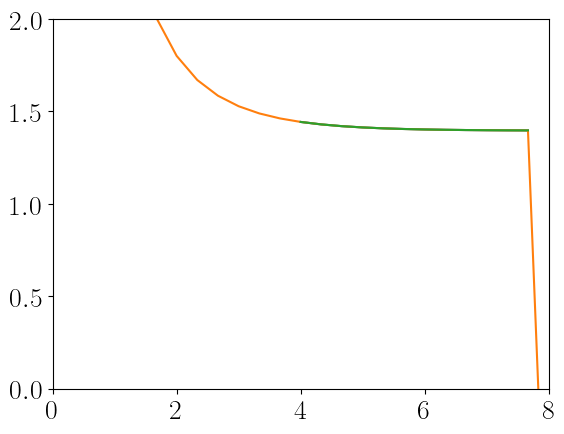

In [41]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [42]:
masses_.append([4, Nt, opt[0][0]])

In [43]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [44]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

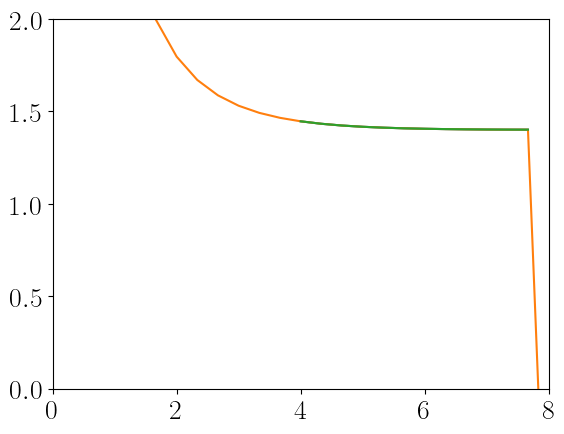

In [45]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [46]:
masses_.append([8, Nt, opt[0][0]])

In [47]:
T=16
Nt=64 # 240

In [48]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

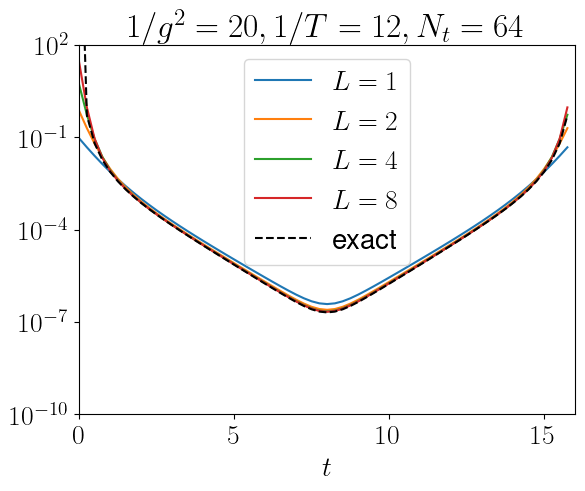

In [49]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [50]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [51]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [52]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

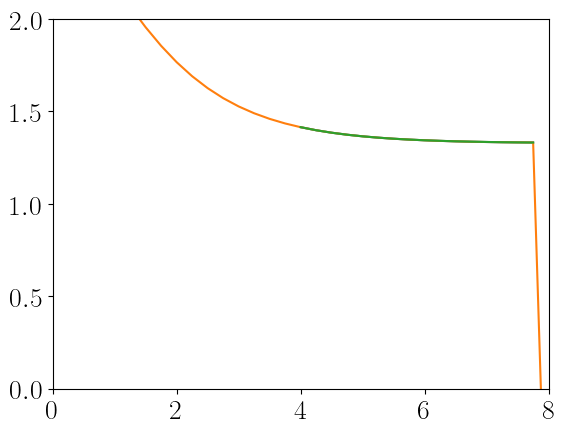

In [53]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [54]:
masses_.append([1, Nt, opt[0][0]])

In [55]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [56]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

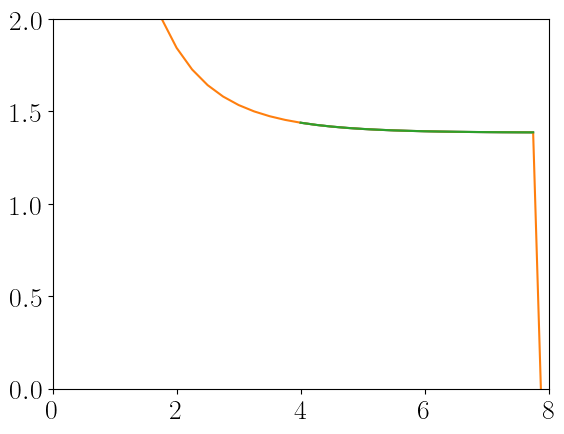

In [57]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [58]:
masses_.append([2, Nt, opt[0][0]])

In [59]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [60]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

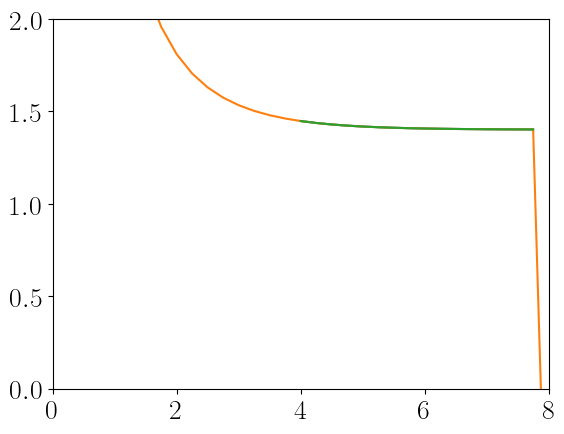

In [61]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [62]:
masses_.append([4, Nt, opt[0][0]])

In [63]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [64]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

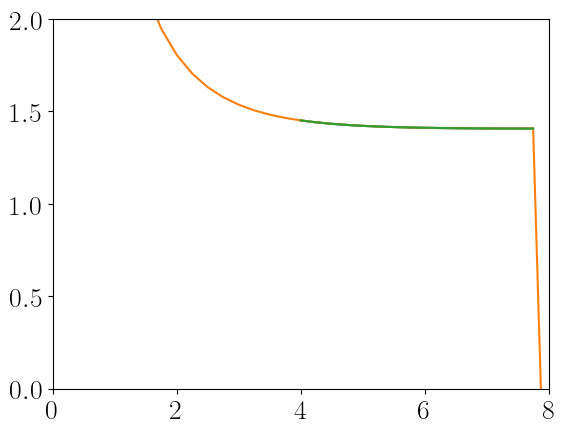

In [65]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [66]:
masses_.append([8, Nt, opt[0][0]])

In [67]:
T=16
Nt=96 # 240

In [68]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

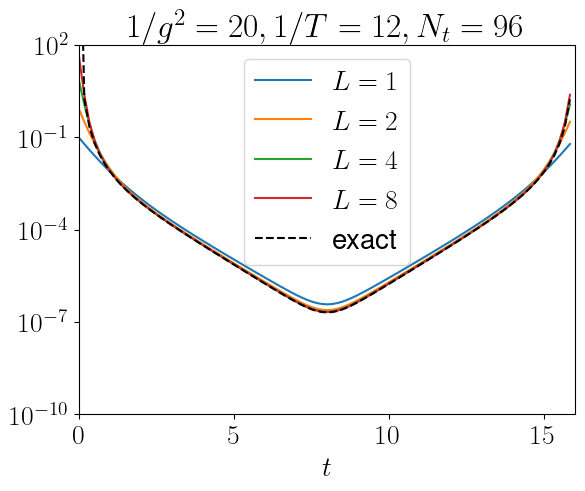

In [69]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [70]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [71]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [72]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

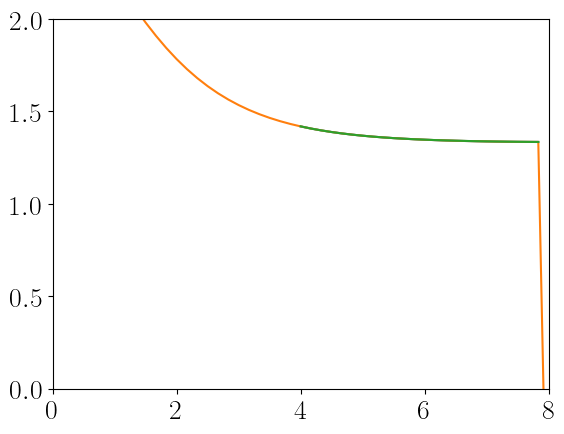

In [73]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [74]:
masses_.append([1, Nt, opt[0][0]])

In [75]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [76]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

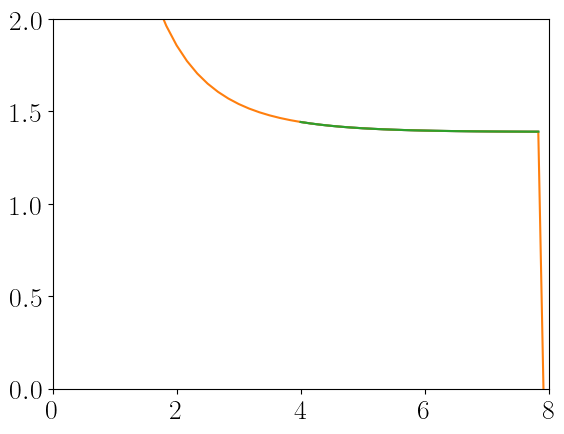

In [77]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [78]:
masses_.append([2, Nt, opt[0][0]])

In [79]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [80]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

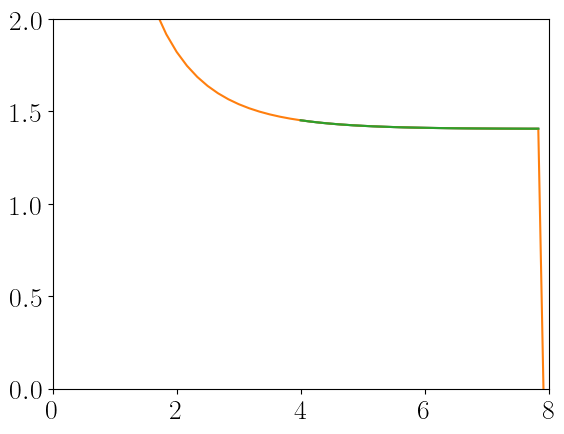

In [81]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [82]:
masses_.append([4, Nt, opt[0][0]])

In [83]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [84]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

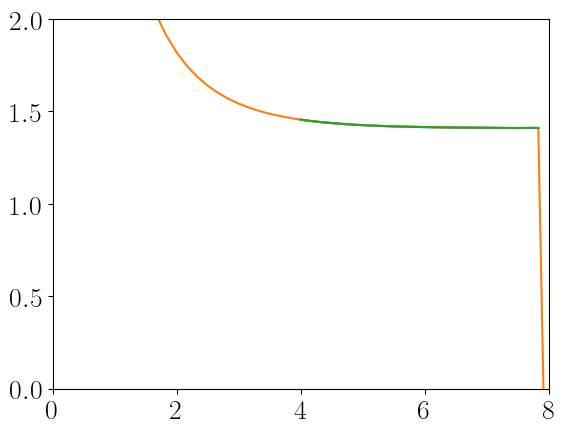

In [85]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [86]:
masses_.append([8, Nt, opt[0][0]])

In [87]:
T=16
Nt=120 # 240

In [88]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

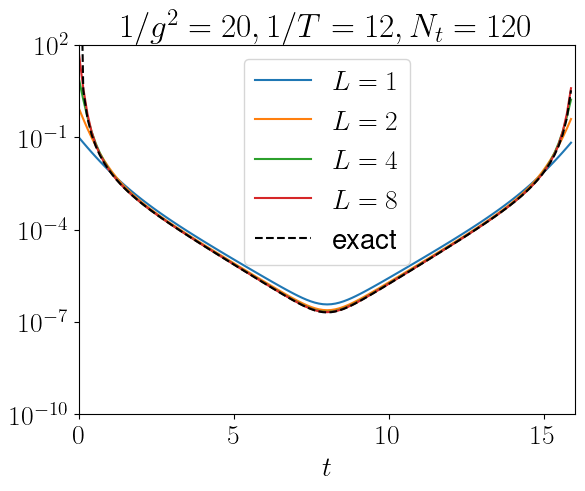

In [89]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [90]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [91]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [92]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

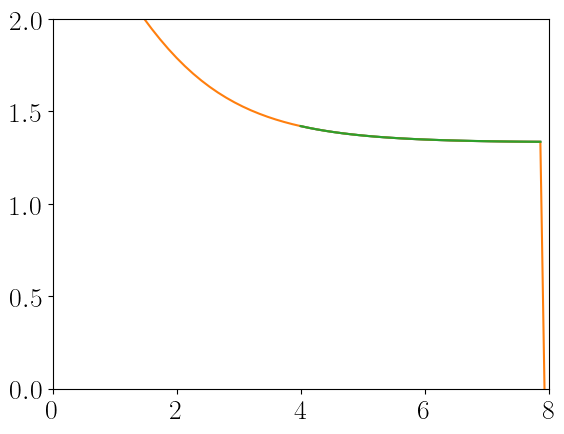

In [93]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [94]:
masses_.append([1, Nt, opt[0][0]])

In [95]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [96]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

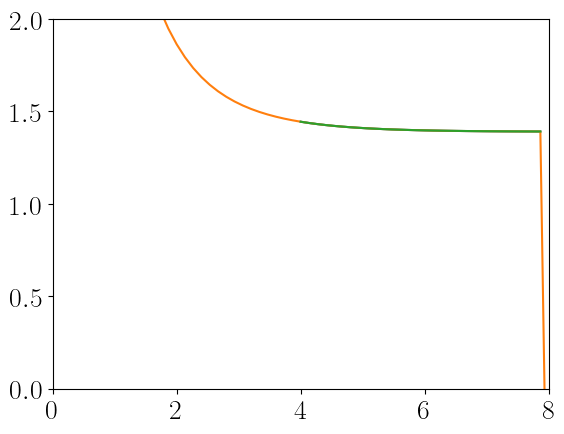

In [97]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [98]:
masses_.append([2, Nt, opt[0][0]])

In [99]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [100]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

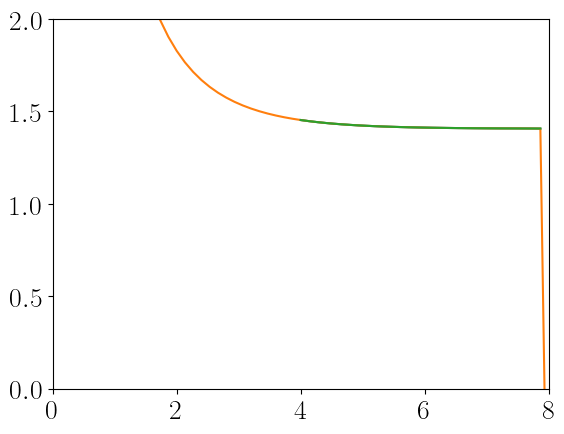

In [101]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [102]:
masses_.append([4, Nt, opt[0][0]])

In [103]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [104]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

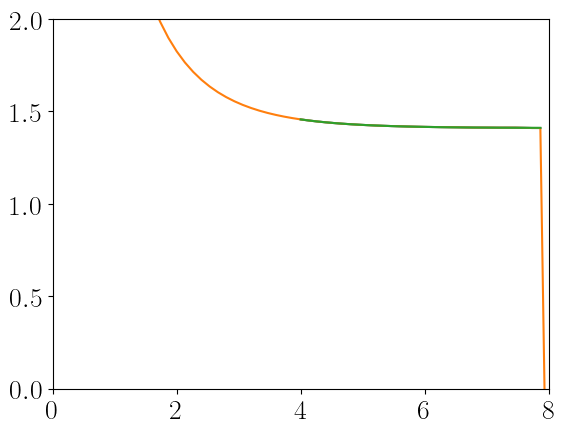

In [105]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [106]:
masses_.append([8, Nt, opt[0][0]])

In [107]:
masses = np.array(masses_)

In [108]:
ells={1:1.107148717794090e+00, 
      2:5.909464448075019e-01, 
      4:2.994744726728921e-01,
      8:1.502274914280941e-01, 
      12:1.002118985797942e-01
     }

In [109]:
masses

array([[  1.        ,  24.        ,   1.29419987],
       [  2.        ,  24.        ,   1.34734272],
       [  4.        ,  24.        ,   1.3620275 ],
       [  8.        ,  24.        ,   1.36553697],
       [  1.        ,  48.        ,   1.32352563],
       [  2.        ,  48.        ,   1.38033369],
       [  4.        ,  48.        ,   1.39623307],
       [  8.        ,  48.        ,   1.40024685],
       [  1.        ,  64.        ,   1.32812044],
       [  2.        ,  64.        ,   1.38554231],
       [  4.        ,  64.        ,   1.40166733],
       [  8.        ,  64.        ,   1.40625448],
       [  1.        ,  96.        ,   1.33145172],
       [  2.        ,  96.        ,   1.38932819],
       [  4.        ,  96.        ,   1.4056286 ],
       [  8.        ,  96.        ,   1.40955513],
       [  1.        , 120.        ,   1.33241985],
       [  2.        , 120.        ,   1.39043277],
       [  4.        , 120.        ,   1.40675842],
       [  8.        , 120.     

In [110]:
a_s = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses ])

In [111]:
def fitter( x, c0, cx, ct ):
    return c0 + cx*x[0]**2 + ct*x[1]**2

In [112]:
opt1= sp.optimize.curve_fit( fitter, a_s.T, masses.T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [113]:
opt1

(array([ 1.41349995, -0.06373471, -0.0999575 ]),
 array([[ 1.23355158e-01, -9.15653863e-02, -2.61687525e-01],
        [-9.15653863e-02,  2.17076133e-01, -1.01989540e-16],
        [-2.61687525e-01, -1.01989540e-16,  1.97169332e+00]]),
 {'fvec': array([-3.25009225e-03, -5.25606819e-04,  1.33085836e-03,  2.09904614e-03,
          7.43310744e-04, -1.97409612e-04,  4.44451802e-04,  7.08335398e-04,
          1.00754829e-03, -5.46985287e-04, -1.30760602e-04, -4.40256019e-04,
          1.14701076e-03, -8.62117144e-04, -6.21285460e-04, -2.70154634e-04,
          1.17845296e-03, -9.67125023e-04, -7.51529278e-04, -9.56923338e-05]),
  'nfev': 9,
  'fjac': array([[-4.47213595e+00,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  

In [114]:
masses2_ = []
for elem in masses:
    if elem[0]!=1:
        masses2_.append(elem)
masses2=np.array(masses2_)

In [115]:
masses2

array([[  2.        ,  24.        ,   1.34734272],
       [  4.        ,  24.        ,   1.3620275 ],
       [  8.        ,  24.        ,   1.36553697],
       [  2.        ,  48.        ,   1.38033369],
       [  4.        ,  48.        ,   1.39623307],
       [  8.        ,  48.        ,   1.40024685],
       [  2.        ,  64.        ,   1.38554231],
       [  4.        ,  64.        ,   1.40166733],
       [  8.        ,  64.        ,   1.40625448],
       [  2.        ,  96.        ,   1.38932819],
       [  4.        ,  96.        ,   1.4056286 ],
       [  8.        ,  96.        ,   1.40955513],
       [  2.        , 120.        ,   1.39043277],
       [  4.        , 120.        ,   1.40675842],
       [  8.        , 120.        ,   1.41038024]])

In [116]:
a_s2 = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses2 ])

In [117]:
opt2= sp.optimize.curve_fit( fitter, a_s2.T, masses2.T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [118]:
opt2

(array([ 1.4135703 , -0.06075866, -0.10352172]),
 array([[ 1.92483427e-01, -5.16875814e-01, -3.48916732e-01],
        [-5.16875814e-01,  3.36018312e+00,  3.02435131e-16],
        [-3.48916732e-01,  3.02435131e-16,  2.62892451e+00]]),
 {'fvec': array([-1.00006933e-03,  8.40133612e-05,  6.52458587e-04,  5.16201718e-04,
          3.85680647e-04,  4.49821688e-04,  3.39886812e-04, -1.62709874e-05,
         -5.25508961e-04,  1.48512647e-04, -3.83038153e-04, -2.31649883e-04,
          7.91469836e-05, -4.77639756e-04, -2.15453678e-05]),
  'nfev': 9,
  'fjac': array([[-3.87298334e+00,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01],
         [-5.14030999e-01, -6.16752534e-01,  4.01705343e-01,
          -1.38760028e-01, -1.38760028e-01, -1.38760028e-01,
          -2.175

In [119]:
opt3= sp.optimize.curve_fit( fitter, a_s[4:].T, masses[4:].T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [120]:
opt3

(array([ 1.41426576, -0.06478071, -0.1062761 ]),
 array([[ 0.25156347, -0.11445674, -2.56944523],
        [-0.11445674,  0.2713452 ,  0.        ],
        [-2.56944523,  0.        , 46.89480891]]),
 {'fvec': array([-4.75106815e-04, -4.98948239e-04,  4.14383404e-04,  7.48470764e-04,
          9.62849836e-05, -5.41369659e-04,  1.46325256e-04, -9.29663979e-05,
          4.55143350e-04, -6.37105619e-04, -1.24803706e-04,  2.96530884e-04,
          5.49771576e-04, -6.78927480e-04, -1.91861506e-04,  5.34179202e-04]),
  'nfev': 9,
  'fjac': array([[-4.00000001,  0.25      ,  0.25      ,  0.25      ,  0.25      ,
           0.25      ,  0.25      ,  0.25      ,  0.25      ,  0.25      ,
           0.25      ,  0.25      ,  0.25      ,  0.25      ,  0.25      ,
           0.25      ],
         [-1.68724914,  1.91972459,  0.25676624,  0.29172794, -0.33503388,
           0.12157357,  0.25676624,  0.29172794, -0.33503388,  0.12157357,
           0.25676624,  0.29172794, -0.33503388,  0.12157357,  0

In [121]:
1.41413851-1.41429151

-0.00015300000000006975

In [122]:
opt4= sp.optimize.curve_fit( fitter, a_s2[4:].T, masses2[4:].T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [123]:
opt4

(array([ 1.41412862, -0.06211257, -0.11059101]),
 array([[ 0.47012706, -0.99300241, -4.91445064],
        [-0.99300241,  5.40735184,  5.17950283],
        [-4.91445064,  5.17950283, 84.75083231]]),
 {'fvec': array([ 3.71000932e-05,  1.92110702e-04, -1.64304532e-05, -2.12056296e-05,
         -4.39574034e-04,  3.76567473e-05, -1.42511430e-04,  9.97464087e-05,
          3.89839571e-05, -1.66420159e-04,  3.80543797e-04]),
  'nfev': 9,
  'fjac': array([[-3.31662478,  0.30151134,  0.30151134,  0.30151134,  0.30151134,
           0.30151134,  0.30151134,  0.30151134,  0.30151134,  0.30151134,
           0.30151134],
         [-0.45126181,  0.44320698, -0.50518277,  0.08039616,  0.23182994,
          -0.50518277,  0.08039616,  0.23182994, -0.50518277,  0.08039616,
           0.23182994],
         [-0.16474265, -0.02708636, -0.10862456, -0.05757086, -0.1416501 ,
          -0.05209888, -0.37722472, -0.46130397, -0.14415864, -0.46928448,
          -0.55336372]]),
  'ipvt': array([1, 2, 3], dtype=

In [124]:
lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )

In [125]:
cs_default = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

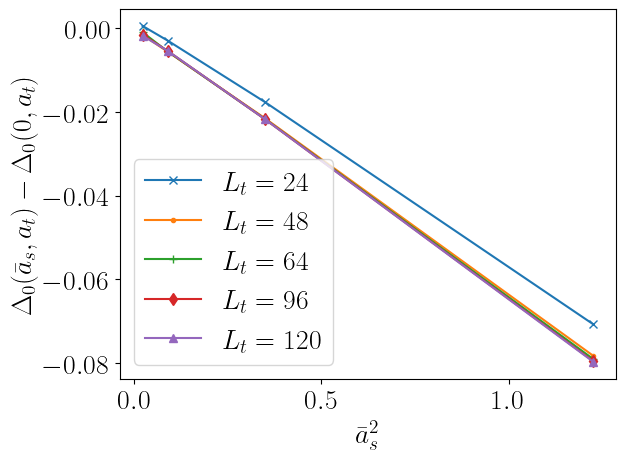

In [127]:
lim = fitter( [0.0, a_s[:4][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[:4].T[0]**2, masses.T[2][:4]-lim, label="$L_t=24$", marker='x', c=cs_default[0] )

lim = fitter( [0.0, a_s[4:8][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[4:8].T[0]**2, masses.T[2][4:8]-lim, label="$L_t=48$", marker='.', c=cs_default[1] )

lim = fitter( [0.0, a_s[8:12][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[8:12].T[0]**2, masses.T[2][8:12]-lim, label="$L_t=64$", marker='+', c=cs_default[2] )

lim = fitter( [0.0, a_s[12:16][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[12:16].T[0]**2, masses.T[2][12:16]-lim, label="$L_t=96$", marker='d', c=cs_default[3] )

lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[16:].T[0]**2, masses.T[2][16:]-lim, label="$L_t=120$", marker='^', c=cs_default[4] )

plt.legend()

plt.xlabel("$\\bar{a}_s^2$")
plt.ylabel("$\\Delta_0(\\bar{a}_s, a_t) - \\Delta_0(0, a_t)$")

plt.savefig("ellbar_scaling_gauge.pdf", bbox_inches="tight")

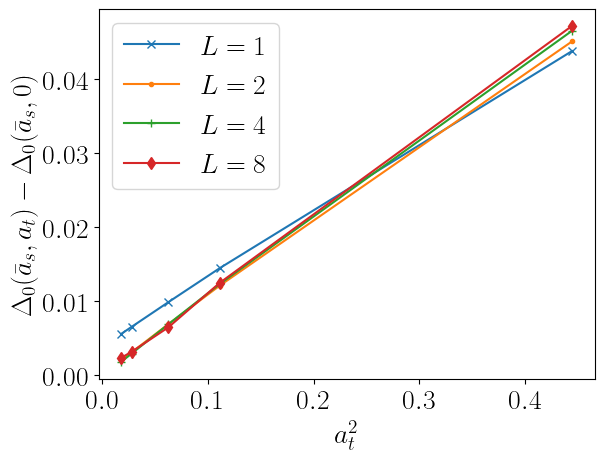

In [128]:
ibase=0
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=1$", marker='x' )

ibase=1
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

ibase=2
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=4$", marker='+' )

ibase=3
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=8$", marker='d' )

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$\\Delta_0(\\bar{a}_s, a_t) - \\Delta_0(\\bar{a}_s, 0)$")

plt.savefig("at_scaling_gauge.pdf", bbox_inches="tight")

In [129]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])

In [130]:
fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )

1.4121625596831142

In [131]:
opt1[0][0]

1.4134999548038671

In [132]:
masses.T[2][::4]

array([1.29419987, 1.32352563, 1.32812044, 1.33145172, 1.33241985])

In [133]:
a_s[::3].T[0]

array([1.10714872, 0.15022749, 0.29947447, 0.59094644, 1.10714872,
       0.15022749, 0.29947447])

In [134]:
a_s[4:8]

array([[1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333]])

In [135]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])